In [37]:
# Helper code
import collections

# An item can be represented as a namedtuple
Item = collections.namedtuple('Item', ['weight', 'value'])

In [38]:
def knapsack(weights, values, capacity):
    n = len(weights)
    dp = [[0] * (capacity + 1) for _ in range(n + 1)]

    # Build table
    for i in range(1, n + 1):
        for w in range(capacity + 1):
            if weights[i - 1] <= w:
                dp[i][w] = max(
                    dp[i - 1][w],                          # Don't take item
                    dp[i - 1][w - weights[i - 1]] + values[i - 1]  # Take item
                )
            else:
                dp[i][w] = dp[i - 1][w]  # Cannot take the item

    return dp[n][capacity]


In [56]:
def knapsack(item_weights, item_values, max_capacity):
    num_items = len(item_weights)
    # dp[i][c] will hold the max value achievable with first i items and capacity c
    dp = [[0] * (max_capacity + 1) for _ in range(num_items + 1)]

    # Build the dp table
    for item_index in range(1, num_items + 1):
        current_weight = item_weights[item_index - 1]
        current_value = item_values[item_index - 1]

        for capacity in range(max_capacity + 1):
            if current_weight <= capacity:
                # Max of not taking or taking the current item
                dp[item_index][capacity] = max(
                    dp[item_index - 1][capacity],  # Not take the current item
                    dp[item_index - 1][capacity - current_weight] + current_value  # Take the item
                )
            else:
                # Cannot take the current item, inherit previous result
                dp[item_index][capacity] = dp[item_index - 1][capacity]

    return dp[num_items][max_capacity]


In [ ]:
def knapsack(weights, values, capacity):
    n = len(weights)
    dp = [[0] * (capacity + 1) for _ in range(n + 1)]

    # Build table
    for i in range(1, n + 1):
        print(f"\nConsidering item {i} (weight={weights[i-1]}, value={values[i-1]}):")
        for w in range(capacity + 1):
            if weights[i - 1] <= w:
                without_item = dp[i - 1][w]
                with_item = dp[i - 1][w - weights[i - 1]] + values[i - 1]
                dp[i][w] = max(without_item, with_item)

                print(
                    f"  Capacity {w}: max(without_item={without_item}, "
                    f"with_item={with_item}) => dp[{i}][{w}] = {dp[i][w]}"
                )
            else:
                dp[i][w] = dp[i - 1][w]
                print(
                    f"  Capacity {w}: item too heavy (item_weight={weights[i-1]}), "
                    f"dp[{i}][{w}] = dp[{i-1}][{w}] = {dp[i][w]}"
                )

    print("\nFinal DP Table:")
    for row in dp:
        print(row)

    return dp[n][capacity]


In [49]:
weights = [2, 1, 3]
values = [4, 2, 3]
capacity = 4

print(knapsack(weights, values, capacity))  # Output: 6



Considering item 1 (weight=2, value=4):
  Capacity 0: item too heavy (item_weight=2), dp[1][0] = dp[0][0] = 0
  Capacity 1: item too heavy (item_weight=2), dp[1][1] = dp[0][1] = 0
  Capacity 2: max(without_item=0, with_item=4) => dp[1][2] = 4
  Capacity 3: max(without_item=0, with_item=4) => dp[1][3] = 4
  Capacity 4: max(without_item=0, with_item=4) => dp[1][4] = 4

Considering item 2 (weight=1, value=2):
  Capacity 0: item too heavy (item_weight=1), dp[2][0] = dp[1][0] = 0
  Capacity 1: max(without_item=0, with_item=2) => dp[2][1] = 2
  Capacity 2: max(without_item=4, with_item=2) => dp[2][2] = 4
  Capacity 3: max(without_item=4, with_item=6) => dp[2][3] = 6
  Capacity 4: max(without_item=4, with_item=6) => dp[2][4] = 6

Considering item 3 (weight=3, value=3):
  Capacity 0: item too heavy (item_weight=3), dp[3][0] = dp[2][0] = 0
  Capacity 1: item too heavy (item_weight=3), dp[3][1] = dp[2][1] = 2
  Capacity 2: item too heavy (item_weight=3), dp[3][2] = dp[2][2] = 4
  Capacity 3: ma

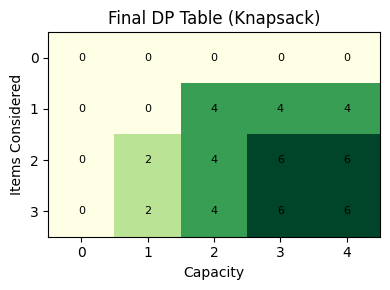

Max Value: 6


In [47]:
import matplotlib.pyplot as plt
import numpy as np

def knapsack(weights, values, capacity):
    n = len(weights)
    dp = [[0] * (capacity + 1) for _ in range(n + 1)]

    # Build the table
    for i in range(1, n + 1):
        for w in range(capacity + 1):
            if weights[i - 1] <= w:
                dp[i][w] = max(
                    dp[i - 1][w],
                    dp[i - 1][w - weights[i - 1]] + values[i - 1]
                )
            else:
                dp[i][w] = dp[i - 1][w]

    return dp

def show_dp_table(dp, weights, values, capacity):
    dp_array = np.array(dp)
    n = len(weights)

    fig, ax = plt.subplots(figsize=(capacity, n))
    ax.set_title("Final DP Table (Knapsack)")

    cmap = plt.cm.YlGn
    ax.imshow(dp_array, cmap=cmap, aspect='auto')

    # Annotate each cell with its value
    for i in range(len(dp_array)):
        for j in range(len(dp_array[0])):
            ax.text(j, i, str(dp_array[i][j]),
                    ha='center', va='center', color='black', fontsize=8)

    ax.set_xlabel("Capacity")
    ax.set_ylabel("Items Considered")
    ax.set_xticks(np.arange(capacity + 1))
    ax.set_yticks(np.arange(n + 1))
    ax.set_xticklabels([str(w) for w in range(capacity + 1)])
    ax.set_yticklabels([str(i) for i in range(n + 1)])

    plt.tight_layout()
    plt.show()

# Example usage
weights = [2, 1, 3]
values = [4, 2, 3]
capacity = 4

dp = knapsack(weights, values, capacity)
show_dp_table(dp, weights, values, capacity)

print("Max Value:", dp[len(weights)][capacity])


<Figure size 640x480 with 0 Axes>

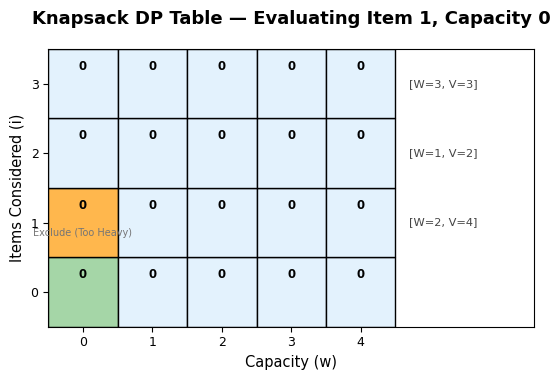

<Figure size 640x480 with 0 Axes>

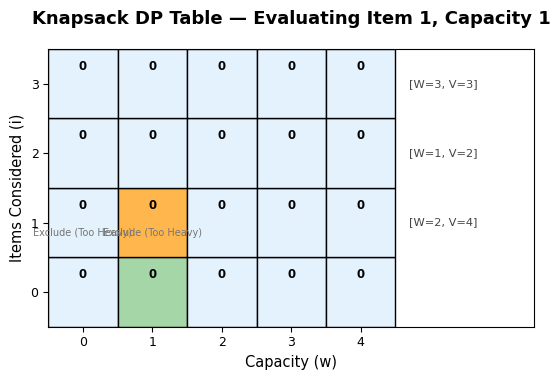

<Figure size 640x480 with 0 Axes>

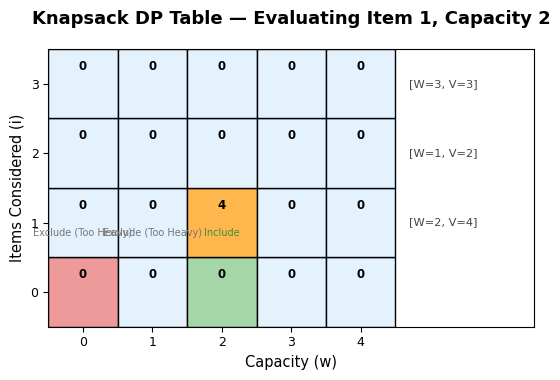

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time

def draw_dp_table(dp, current_i=None, current_w=None, weights=None, values=None, decisions=None, compare_cells=None):
    plt.clf()
    num_items, capacity = len(dp), len(dp[0])
    fig_width = capacity + 1.8
    fig, ax = plt.subplots(figsize=(fig_width, num_items * 0.6 + 1.5))

    ax.set_title(f"Knapsack DP Table — Evaluating Item {current_i}, Capacity {current_w}",
                 fontsize=13, fontweight='bold', pad=18)

    for i in range(num_items):
        for w in range(capacity):
            val = dp[i][w]
            cell_color = '#E3F2FD'

            # Highlight compared cells
            if compare_cells and (i, w) in compare_cells:
                color_index = compare_cells.index((i, w))
                cell_color = '#A5D6A7' if color_index == 0 else '#EF9A9A'  # green for exclude, red for include

            # Highlight the current cell
            if i == current_i and w == current_w:
                cell_color = '#FFB74D'

            ax.add_patch(
                plt.Rectangle((w, num_items - i - 1), 1, 1, fill=True, facecolor=cell_color, edgecolor='black')
            )
            ax.text(w + 0.5, num_items - i - 0.75, f'{val}',
                    ha='center', va='center', fontsize=8.5, fontweight='bold')

            if decisions and decisions[i][w]:
                decision = decisions[i][w]
                text_color = (
                    '#388E3C' if decision == "Include"
                    else '#D32F2F' if "Skipped" in decision
                    else '#757575'
                )
                ax.text(w + 0.5, num_items - i - 0.35, decision,
                        ha='center', va='center', fontsize=7, color=text_color)

        if weights and values and i > 0:
            item_index = i - 1
            ax.text(capacity + 0.2, num_items - i - 0.5,
                    f"[W={weights[item_index]}, V={values[item_index]}]",
                    ha='left', va='center', fontsize=8.2, fontweight='normal', color='#444')

    ax.set_xticks(np.arange(capacity) + 0.5)
    ax.set_xticklabels([str(i) for i in range(capacity)], fontsize=9)
    ax.set_yticks(np.arange(num_items) + 0.5)
    ax.set_yticklabels([str(i) for i in range(num_items - 1, -1, -1)], fontsize=9)

    ax.set_xlabel("Capacity (w)", fontsize=10.5)
    ax.set_ylabel("Items Considered (i)", fontsize=10.5)

    ax.set_xlim(0, capacity + 2)
    ax.set_ylim(0, num_items)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.grid(False)
    plt.tight_layout()
    plt.pause(0.4)




def knapsack_visual(weights, values, capacity):
    num_items = len(weights)
    dp = [[0] * (capacity + 1) for _ in range(num_items + 1)]
    decisions = [[""] * (capacity + 1) for _ in range(num_items + 1)]

    plt.ion()

    for i in range(1, num_items + 1):
        for w in range(capacity + 1):
            compare_cells = []
            if weights[i - 1] <= w:
                include_val = dp[i - 1][w - weights[i - 1]] + values[i - 1]
                exclude_val = dp[i - 1][w]
                compare_cells = [(i - 1, w), (i - 1, w - weights[i - 1])]

                if include_val > exclude_val:
                    dp[i][w] = include_val
                    decisions[i][w] = "Include"
                else:
                    dp[i][w] = exclude_val
                    decisions[i][w] = "Exclude (Skipped)"
            else:
                dp[i][w] = dp[i - 1][w]
                decisions[i][w] = "Exclude (Too Heavy)"
                compare_cells = [(i - 1, w)]

            draw_dp_table(dp, i, w, weights, values, decisions, compare_cells)

    plt.ioff()
    plt.show()
    return dp[num_items][capacity]



# Example usage
if __name__ == "__main__":
    weights = [2, 1, 3]
    values = [4, 2, 3]
    capacity = 4
    result = knapsack_visual(weights, values, capacity)
    print("\nMaximum Value Achievable:", result)


You are given access to yesterday's stock prices for a single stock. The data is in the form of an array with the stock price in 30 minute intervals from 9:30 a.m EST opening to 4:00 p.m EST closing time. With this data, write a function that returns the maximum profit obtainable. You will need to buy before you can sell.

For example, suppose you have the following prices:

`prices = [3, 4, 7, 8, 6]`

>Note: This is a shortened array, just for the sake of example—a full set of prices for the day would have 13 elements (one price for each 30 minute interval betwen 9:30 and 4:00), as seen in the test cases further down in this notebook.

In order to get the maximum profit in this example, you would want to buy at a price of 3 and sell at a price of 8 to yield a maximum profit of 5. In other words, you are looking for the greatest possible difference between two numbers in the array.


### The Idea
The given array has the prices of a single stock at 13 different timestamps. The idea is to pick two timestamps:
"buy_at_min" and "sell_at_max" such that the buy is made before a sell. We will use two pairs of indices while traversing the array: 
* **Pair 1** - This pair keeps track of our maximum profit while iterating over the list. It is done by storing a pair of indices - `min_price_index`, and `max_price_index`. 
* **Pair 2** -  This pair keeps track of the profit between the lowest price seen so far and the current price while traversing the array. The lowest price seen so far is maintained with `current_min_price_index`.

At each step we will make the greedy choice by choosing prices such that our profit is maximum. We will store the **maximum of either of the two profits mentioned above**. 

  
    

### Exercise - Write the function definition here
Fill out the function below and run it against the test cases. Take into consideration the time complexity of your solution. 

In [1]:
def max_returns(prices):
    if not prices or len(prices) < 2:
        return 0  # Cannot make a profit with fewer than 2 prices

    min_price = prices[0]
    max_profit = 0

    for price in prices[1:]:
        profit = price - min_price
        max_profit = max(max_profit, profit)
        min_price = min(min_price, price)

    return max_profit

In [6]:
def max_returns(prices):
    if not prices or len(prices) < 2:
        return 0

    min_price = prices[0]
    max_profit = 0

    print(f"{'Index':<5} {'Price':<6} {'Min Price':<10} {'Profit':<8} {'Max Profit':<10}")
    for i in range(1, len(prices)):
        price = prices[i]
        profit = price - min_price
        max_profit = max(max_profit, profit)
        min_price = min(min_price, price)

        print(f"{i:<5} {price:<6} {min_price:<10} {profit:<8} {max_profit:<10}")

    return max_profit


In [7]:
# Test Cases
def test_function(test_case):
    prices = test_case[0]
    solution = test_case[1]
    output = max_returns(prices)
    if output == solution:
        print("Pass")
    else:
        print("Fail")

In [8]:
prices = [2, 2, 7, 9, 9, 12, 18, 23, 34, 37, 45, 54, 78]
solution = 76
test_case = [prices, solution]
test_function(test_case)

Index Price  Min Price  Profit   Max Profit
1     2      2          0        0         
2     7      2          5        5         
3     9      2          7        7         
4     9      2          7        7         
5     12     2          10       10        
6     18     2          16       16        
7     23     2          21       21        
8     34     2          32       32        
9     37     2          35       35        
10    45     2          43       43        
11    54     2          52       52        
12    78     2          76       76        
Pass


In [9]:
prices = [54, 18, 37, 9, 11, 48, 23, 1, 7, 34, 2, 45, 67]
solution = 66
test_case = [prices, solution]
test_function(test_case)

Index Price  Min Price  Profit   Max Profit
1     18     18         -36      0         
2     37     18         19       19        
3     9      9          -9       19        
4     11     9          2        19        
5     48     9          39       39        
6     23     9          14       39        
7     1      1          -8       39        
8     7      1          6        39        
9     34     1          33       39        
10    2      1          1        39        
11    45     1          44       44        
12    67     1          66       66        
Pass


In [10]:
prices = [78, 54, 45, 37, 34, 23, 18, 12, 9, 9, 7, 2, 2]
solution = 0
test_case = [prices, solution]
test_function(test_case)

Index Price  Min Price  Profit   Max Profit
1     54     54         -24      0         
2     45     45         -9       0         
3     37     37         -8       0         
4     34     34         -3       0         
5     23     23         -11      0         
6     18     18         -5       0         
7     12     12         -6       0         
8     9      9          -3       0         
9     9      9          0        0         
10    7      7          -2       0         
11    2      2          -5       0         
12    2      2          0        0         
Pass


In [14]:
import matplotlib.pyplot as plt

def visualize_max_returns(prices):
    min_price = prices[0]
    max_profit = 0
    buy_day = sell_day = 0

    for i in range(1, len(prices)):
        profit = prices[i] - min_price
        if profit > max_profit:
            max_profit = profit
            sell_day = i
        if prices[i] < min_price:
            min_price = prices[i]
            buy_day = i

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(prices, marker='o')
    plt.scatter([buy_day], [prices[buy_day]], color='green', label=f"Buy (${prices[buy_day]})", zorder=5)
    plt.scatter([sell_day], [prices[sell_day]], color='red', label=f"Sell (${prices[sell_day]})", zorder=5)
    plt.title("Stock Prices & Max Profit Opportunity")
    plt.xlabel("Interval Index")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Buy at index {buy_day} (${prices[buy_day]}), sell at index {sell_day} (${prices[sell_day]}), profit = ${max_profit}")


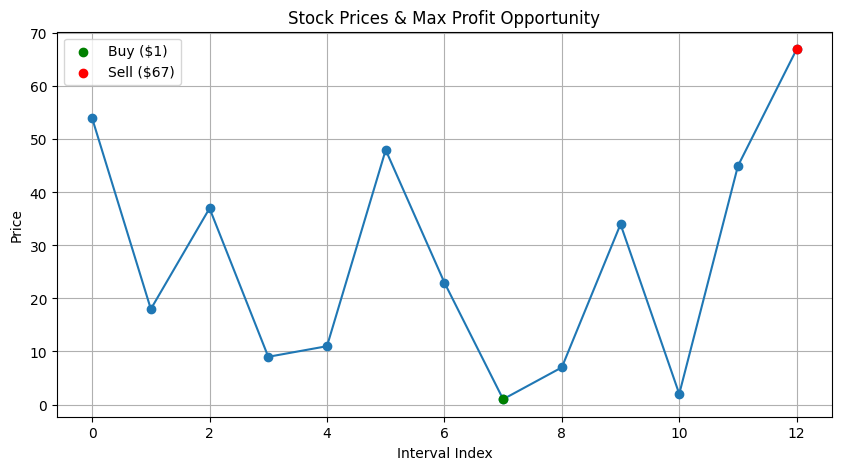

Buy at index 7 ($1), sell at index 12 ($67), profit = $66


In [16]:
visualize_max_returns([54, 18, 37, 9, 11, 48, 23, 1, 7, 34, 2, 45, 67])


# Coin Change

You are given coins of different denominations and a total amount of money. Write a function to compute the fewest coins needed to make up that amount. If that amount of money cannot be made up by any combination of the coins, return `-1`.

As an example:
* Input: `coins = [1, 2, 3]`, `amount = 6`
* Output: `2`
* Explanation: The output is `2` because we can use `2` coins with value `3`. That is, `6 = 3 + 3`. We could also use `3` coins with value `2` (that is, `6 = 2 + 2 + 2`), but this would use more coins—and the problem specifies we should use the smallest number of coins possible.

There's test code below that you can use to check your solution. And at the bottom of the notebook, you'll find two different possible solutions.

In [32]:
def coin_change(coins, amount):
    # Initialize the DP array with a value greater than the possible number of coins (amount + 1)
    dp = [float('inf')] * (amount + 1)
    dp[0] = 0  # Base case: 0 coins to make amount 0

    # Build up the dp array
    for coin in coins:
        for x in range(coin, amount + 1):
            dp[x] = min(dp[x], dp[x - coin] + 1)

    # If dp[amount] is still infinity, return -1 (not possible to make amount)
    return dp[amount] if dp[amount] != float('inf') else -1



In [29]:
def coin_change(coins, amount):
    dp = [float('inf')] * (amount + 1)
    dp[0] = 0

    for coin in coins:
        print(f"Using coin: {coin}")
        for x in range(coin, amount + 1):
            print(f"  Comparing: dp[{x - coin}] + 1 = {dp[x - coin]} + 1 = {dp[x - coin] + 1} < dp[{x}] = {dp[x]}")
            if dp[x - coin] + 1 < dp[x]:
                print(f"  Updating dp[{x}] from {dp[x]} to {dp[x - coin] + 1} (using coin {coin})")
            dp[x] = min(dp[x], dp[x - coin] + 1)
        print(f"DP after using coin {coin}: {dp}")

    result = dp[amount] if dp[amount] != float('inf') else -1
    print(f"Final DP array: {dp}")
    print(f"Result: {result}")
    return result


In [30]:
def test_function(test_case):
    arr = test_case[0]
    amount = test_case[1]
    solution = test_case[2]
    output = coin_change(arr, amount)
    if output == solution:
        print("Pass")
    else:
        print("Fail")

In [31]:
arr = [1,2,5]
amount = 11
solution = 3
test_case = [arr, amount, solution]
test_function(test_case)

Using coin: 1
  Comparing: dp[0] + 1 = 0 + 1 = 1 < dp[1] = inf
  Updating dp[1] from inf to 1 (using coin 1)
  Comparing: dp[1] + 1 = 1 + 1 = 2 < dp[2] = inf
  Updating dp[2] from inf to 2 (using coin 1)
  Comparing: dp[2] + 1 = 2 + 1 = 3 < dp[3] = inf
  Updating dp[3] from inf to 3 (using coin 1)
  Comparing: dp[3] + 1 = 3 + 1 = 4 < dp[4] = inf
  Updating dp[4] from inf to 4 (using coin 1)
  Comparing: dp[4] + 1 = 4 + 1 = 5 < dp[5] = inf
  Updating dp[5] from inf to 5 (using coin 1)
  Comparing: dp[5] + 1 = 5 + 1 = 6 < dp[6] = inf
  Updating dp[6] from inf to 6 (using coin 1)
  Comparing: dp[6] + 1 = 6 + 1 = 7 < dp[7] = inf
  Updating dp[7] from inf to 7 (using coin 1)
  Comparing: dp[7] + 1 = 7 + 1 = 8 < dp[8] = inf
  Updating dp[8] from inf to 8 (using coin 1)
  Comparing: dp[8] + 1 = 8 + 1 = 9 < dp[9] = inf
  Updating dp[9] from inf to 9 (using coin 1)
  Comparing: dp[9] + 1 = 9 + 1 = 10 < dp[10] = inf
  Updating dp[10] from inf to 10 (using coin 1)
  Comparing: dp[10] + 1 = 10 + 1

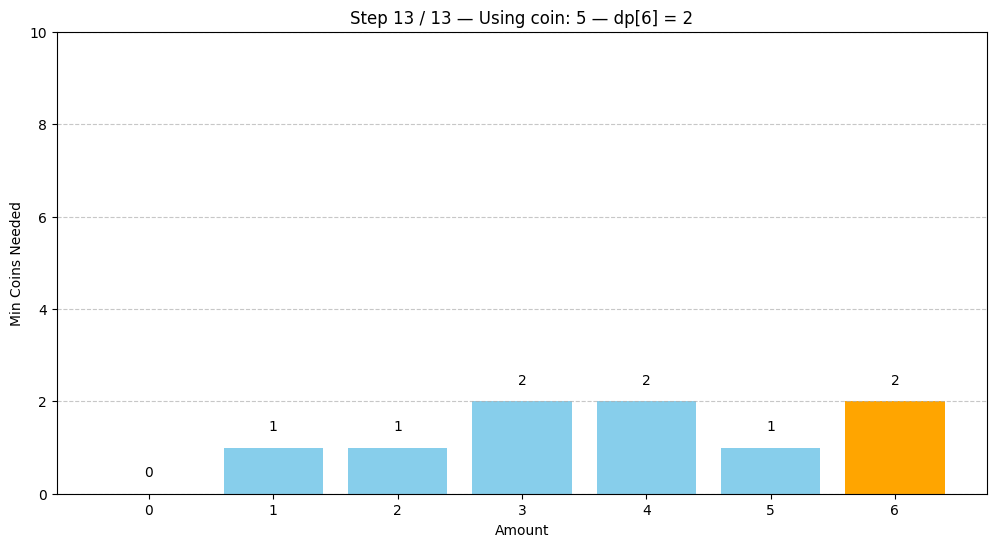

In [36]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

def coin_change_with_visual(coins, amount):
    dp = [float('inf')] * (amount + 1)
    dp[0] = 0
    snapshots = []
    updates = []  # store indices updated at each step
    used_coins = []  # store which coin caused update
    
    snapshots.append(dp.copy())  # initial state
    updates.append([])
    used_coins.append(None)
    
    for coin in coins:
        for x in range(coin, amount + 1):
            if dp[x - coin] + 1 < dp[x]:
                dp[x] = dp[x - coin] + 1
                snapshots.append(dp.copy())
                updates.append([x])  # only one position updated per step here
                used_coins.append(coin)
    result = dp[amount] if dp[amount] != float('inf') else -1
    return result, snapshots, updates, used_coins

def plot_snapshots_jupyter_v2(snapshots, updates, used_coins, amount):
    for step, dp in enumerate(snapshots):
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(12, 6))
        
        bar_colors = ['skyblue'] * (amount + 1)
        # Highlight updated bars in a different color
        for idx in updates[step]:
            bar_colors[idx] = 'orange'
        
        bars = ax.bar(range(amount+1), [x if x != float('inf') else amount+1 for x in dp], color=bar_colors)
        
        ax.set_ylim(0, max(amount, 10))
        ax.set_xticks(range(amount+1))
        ax.set_xlabel('Amount')
        ax.set_ylabel('Min Coins Needed')
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        coin = used_coins[step]
        title_coin = f"Using coin: {coin}" if coin else "Initial State"
        ax.set_title(f'Step {step} / {len(snapshots)-1} — {title_coin} — dp[{amount}] = {dp[amount] if dp[amount]!=float("inf") else "∞"}')
        
        # Add dp values on top of bars
        for rect, val in zip(bars, dp):
            height = rect.get_height()
            label = '∞' if val == float('inf') else str(val)
            ax.text(rect.get_x() + rect.get_width()/2, height + 0.3, label, ha='center', va='bottom', fontsize=10)
        
        plt.show()
        time.sleep(0.6)  # a bit longer pause so you see the updates clearly

# Run example:
coins = [1, 2, 5]
amount = 6

result, snapshots, updates, used_coins = coin_change_with_visual(coins, amount)
print(f"Minimum coins to make {amount}: {result}")

plot_snapshots_jupyter_v2(snapshots, updates, used_coins, amount)


# Longest Palindromic Subsequence

In general, a palindrome is a string that reads the same backwards as forwards, e.g., `MADAM`. In the last notebook, we saw that in a given string, a subsequence is an ordered set of characters that need not necessarily be a contiguous substring, e.g., `ABC` is a subsequence in `AXBYC` with `length = 3`. 

The **Longest Palindromic Subsequence** (LPS) is the most lengthy sequence of characters that is a palindrome. In this notebook, you'll be tasked with finding the **length of the LPS in a given string of characters**.

Examples:
1. With an input string, `MAXDYAM`, the LPS is `MADAM`, which has `length = 5`
1. With an input string, `BxAoNxAoNxA`, the LPS is `ANANA`, which has `length = 5`
1. With an input string, `BANANO`, the LPS is `NAN`, which has `length = 3`
1. With an input string, `ABBDBCACB`, the LPS is `BCACB`, which has `length = 5`

In this notebook, we'll focus on finding an optimal solution to finding the length of the LPS task, using dynamic programming. There will be some similarities to the Longest Common Subsequence (LCS) task, which is outlined in detail in a previous notebook. It is recommended that you start with that notebook before trying out this task.

## Dynamic Programming Approach - Storing Pre-Computed Values

Similar to how you compared **two strings** in the LCS (Longest Common Subsequence) task, you can compare the characters in just **one string** with itself, in this LPS task. 

* The LPS solution algorithm depends on how the characters of a given string are related to each other. 

* For a string of length *n* characters, you can build an `n x n` matrix. The 2-D matrix will have characters of the given string on the top as well as on the left side.

* The matrix will store the solution to **smaller subproblems** first, and gradually adding up more characters to the problem. In this case, **a subproblem is to find the length of the LPS, up to a certain point in the string**. 


Read the rules below to fill up the matrix cells. 